# 第 7 天：Capstone 成果包与机制解释

把 trajectory、evaluation、verification 和 mechanism explanation 整理成可审核成果包。

今天把前六天的工作打包成研究型 artifact：它不仅要得分，还要能回放、能解释、能说明失败模式。


## 学习路径定位

| 项目 | 内容 |
| --- | --- |
| 阶段 | C. 形成项目 |
| 难度 | 进阶到挑战 |
| 先修 | 已能运行 baseline，理解 trajectory、manifest、results 的作用。 |
| 今天只解决 | 把前六天的实验、模型、策略和解释整理成可复现小项目。 |
| 今天不要求 | 不要求 private-eval，也不要求最终模型最强。 |
| 本日交付 | 小型 submission bundle：manifest、trajectory、results、explanation。 |
| 下一步如何复用 | Day 8 会把 GPT-style planner 纳入同一套验证流程。 |



## 课堂时间盒：每 30 分钟都有产出

建议按 3 小时工作坊使用。每一段都要留下一个小证据，不要只运行代码看到结果就继续往下翻。

| 时间 | 阶段目标 | 具体动作 | 当段产出 |
| --- | --- | --- | --- |
| 0:00-0:30 | 选择最佳策略 | 回顾前 6 天结果，确定一个候选 recipe 或 agent。 | 写出策略说明。 |
| 0:30-1:00 | 复现实验运行 | 固定 seed 重新运行策略。 | 得到复现轨迹。 |
| 1:00-1:30 | 验证轨迹 | 运行 verify 或检查 replay 字段。 | 确认可回放。 |
| 1:30-2:00 | 评估指标 | 计算 score、risk、cost、sample efficiency。 | 得到评价 JSON。 |
| 2:00-2:30 | 机制解释 | 写温度、时间、副反应、安全的证据链。 | 得到 explanation 草稿。 |
| 2:30-3:00 | 打包 artifact | 整理 trajectory、manifest、results、explanation。 | 形成小型提交包。 |

教师提示：如果课堂时间少于 3 小时，可以把最后两个时间盒改成课后提交；但前四个时间盒建议现场完成。


## 本日任务梯度

| 层级 | 任务 |
| --- | --- |
| 基础任务 | 生成并验证一份最小提交包。 |
| 进阶任务 | 补充策略说明和机制解释，使别人能复现实验。 |
| 挑战任务 | 把失败案例也写进 failure analysis，而不是只保留成功结果。 |
| 反思问题 | 如果别人拿到你的提交包，能否不问你就复现实验结论？ |



## 三小时实验工单（必须自己完成）

这一节不是演示输出，而是当天真正的工作量。请不要只从上到下运行已有单元；必须在后面的学生工作区新增自己的实验、图表、表格和文字结论。

| 序号 | 最小完成量 |
| --- | --- |
| 1 | 整理至少 1 个完整 submission bundle：manifest、trajectory、results、explanation。 |
| 2 | 至少 replay/verify 2 条轨迹：一条成功轨迹，一条失败或低分轨迹。 |
| 3 | 补齐 failure analysis：至少解释 2 个失败原因和对应修复方案。 |
| 4 | 写 500 字项目摘要，让别人不问你也能复现实验结论。 |

验收口径：本日交付至少应包含数据表、图或谱图、验证/评测结果、机制解释和下一步实验建议。低于这些证据量，视为只完成了演示浏览。



## 学生工作区

请从这里开始写自己的实验扩展。建议保留上方演示单元作为参考，不要直接覆盖；把你新增的实验条件、图、模型、验证结果和文字结论放在下面。

建议你在本节下面新增自己的代码单元。可从这个记录模板开始：

```python
student_work = {
    "hypothesis": "",
    "experiments_added": 0,
    "figures_created": 0,
    "verification_or_metric": "",
    "next_experiment": "",
}
```



In [1]:
import importlib
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks" / "tutorials"))

tu = importlib.import_module("tutorial_utils")

pd.set_option("display.precision", 4)
OUTPUT_DIR = tu.ensure_output(7)
print("project root:", ROOT)
print("output dir:", OUTPUT_DIR)

project root: D:\Projects\ChemWorld
output dir: D:\Projects\ChemWorld\runs\tutorials\day07


## 今日任务

请先运行顶部导入单元，确认 kernel 指向项目虚拟环境；随后按顺序执行每个代码单元，观察表格、图形和验证结果，并在最后写下自己的实验判断。


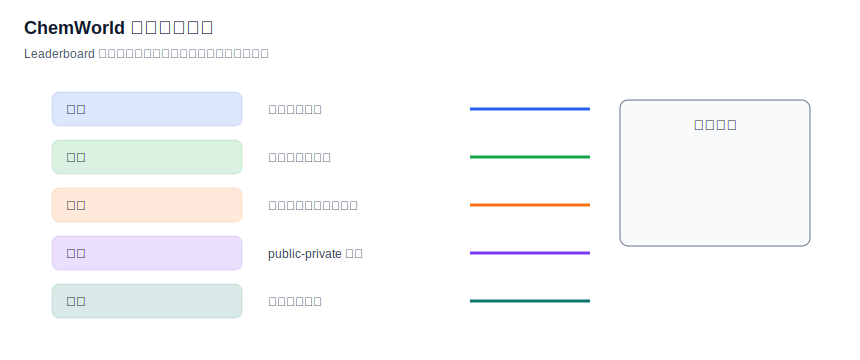

In [2]:
tu.display_tutorial_header(
    day=7,
    title='Capstone 成果包与机制解释',
    subtitle='把 trajectory、evaluation、verification 和 mechanism explanation 整理成可审核成果包。',
    focus=[
        'trajectory JSONL',
        'replay verification',
        'evaluation metrics',
        '机制解释',
    ],
    deliverables=[
        '一份 JSONL artifact',
        '一份 verify 报告',
        '一张机制解释卡',
    ],
    project_link='正式提交不是截图，而是一组可复现、可验证、可解释的文件。',
)
tu.display_course_map(7)
display(tu.leaderboard_blueprint_svg())


In [3]:
tu.display_api_card()

## 第 7 天检查点

完成本 notebook 后，请确认你已经留下这些证据：

- 一张来自自己实验的轨迹表或 JSONL 文件
- 一张由自己实验数据生成的图
- 一个有化工意义的机制假设
- 一个下一轮实验建议
- 一条关于 GPT 或其他助手使用方式的记录


,candidate,temperature_C,time_h,catalyst,solvent,yield,degradation,risk,score
0,C1,70.0,0.50,cat_b,ethanol,0.6063,0.1246,0.0832,0.4786
1,C2,95.0,0.40,cat_b,acetonitrile,0.4369,0.3137,0.1265,0.3367
2,C3,120.0,0.25,cat_a,acetonitrile,0.3226,0.3466,0.1752,0.2532
3,C4,85.0,0.80,cat_d,ethanol,0.3887,0.3522,0.1149,0.2981


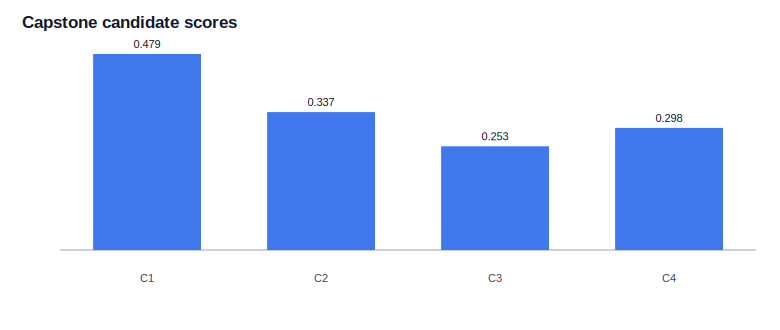

In [5]:
candidate_recipes = [
    {
        "temperature": 70.0,
        "time": 0.50,
        "initial_concentration": 0.35,
        "stirring_speed": 650.0,
        "catalyst": 1,
        "solvent": 1,
    },
    {
        "temperature": 95.0,
        "time": 0.40,
        "initial_concentration": 0.45,
        "stirring_speed": 760.0,
        "catalyst": 1,
        "solvent": 2,
    },
    {
        "temperature": 120.0,
        "time": 0.25,
        "initial_concentration": 0.30,
        "stirring_speed": 800.0,
        "catalyst": 0,
        "solvent": 2,
    },
    {
        "temperature": 85.0,
        "time": 0.80,
        "initial_concentration": 0.55,
        "stirring_speed": 700.0,
        "catalyst": 3,
        "solvent": 1,
    },
]

capstone_seed = 77
capstone_rows = []
for index, recipe in enumerate(candidate_recipes):
    result = tu.run_recipe(recipe, split="public-test", seed=capstone_seed)
    result["candidate"] = f"C{index + 1}"
    capstone_rows.append(result)
capstone_df = pd.DataFrame(capstone_rows)
display(
    capstone_df[
        [
            "candidate",
            "temperature_C",
            "time_h",
            "catalyst",
            "solvent",
            "yield",
            "degradation",
            "risk",
            "score",
        ]
    ]
)
display(
    tu.bar_svg(
        capstone_df["candidate"].tolist(),
        capstone_df["score"].astype(float).tolist(),
        title="Capstone candidate scores",
        color="#2563eb",
    )
)

In [6]:
best_index = int(capstone_df["score"].to_numpy().argmax())
best_row = capstone_df.iloc[best_index]
best_recipe = candidate_recipes[best_index]
tu.show_json_panel(
    "Best condition from candidate set",
    {
        "candidate": best_row["candidate"],
        "temperature_C": float(best_row["temperature_C"]),
        "time_h": float(best_row["time_h"]),
        "catalyst": best_row["catalyst"],
        "solvent": best_row["solvent"],
        "score": float(best_row["score"]),
        "risk": float(best_row["risk"]),
    },
)

In [7]:
from chemworld.eval.metrics import evaluate_records
from chemworld.eval.verify import verify_records

trajectory_path = OUTPUT_DIR / "best_candidate_capstone.jsonl"
records = tu.write_recipe_trajectory(
    best_recipe,
    trajectory_path,
    split="public-test",
    seed=capstone_seed,
    objective="balanced",
    agent_name="capstone_best_candidate_replay",
)
evaluation = evaluate_records(records).to_dict()
verification = verify_records(records).to_dict()
tu.show_json_panel("Evaluation", evaluation)
tu.show_json_panel("Replay verification", verification)

,step,operation,instrument,reward,leaderboard_score,yield,risk,observed_keys
0,1,add_solvent,None,0.0000,NaN,NaN,0.0597,"cost, safety_risk, score"
1,2,add_reagent,None,0.0000,NaN,NaN,0.0777,"cost, safety_risk, score"
2,3,add_catalyst,None,0.0000,NaN,NaN,0.0777,"cost, safety_risk, score"
3,4,heat,None,0.0000,NaN,NaN,0.0832,"cost, safety_risk, score"
4,5,terminate,None,0.0000,NaN,NaN,0.0832,"cost, safety_risk, score"
5,6,measure,final_assay,0.4786,0.4786,0.6063,0.0832,"yield, selectivity, conversion, byproduct_sign..."


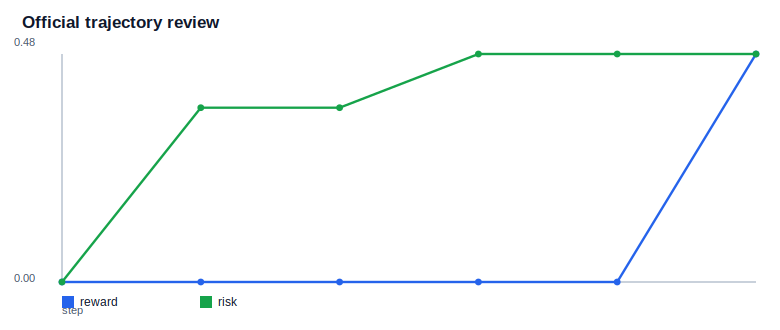

In [8]:
trajectory_df = pd.DataFrame(
    [
        {
            "step": record["step"],
            "operation": record["operation_type"],
            "instrument": record["instrument"],
            "reward": record["reward"],
            "leaderboard_score": record["leaderboard_score"],
            "yield": record["observation"]["yield"],
            "risk": record["observation"]["safety_risk"],
            "observed_keys": ", ".join(record["observed_keys"]),
        }
        for record in records
    ]
)
display(trajectory_df)
display(
    tu.line_svg(
        trajectory_df,
        x="step",
        ys=["reward", "risk"],
        title="Official trajectory review",
    )
)
assert (trajectory_df["instrument"] == "final_assay").sum() == 1
assert trajectory_df["leaderboard_score"].notna().sum() == 1

In [9]:
explanation = {
    "selected_candidate": str(best_row["candidate"]),
    "hypothesis": (
        "Moderate temperature and moderate time should improve yield before degradation dominates."
    ),
    "learned_mechanism": (
        "The scans suggest a yield/degradation trade-off and meaningful "
        "catalyst-solvent interactions."
    ),
    "failure_analysis": (
        "Single-seed candidate testing is not enough for a claim; private "
        "world generalization must be evaluated."
    ),
    "next_experiment_rationale": (
        "Run a small local design around the selected candidate while adding "
        "risk-aware constraints and at least one cheap mid-run observation."
    ),
}
tu.show_json_panel("Structured explanation", explanation)

## 最终交付清单

一个合格的 ChemWorld-Bench 小型提交至少应包含：

- 你的策略说明；
- trajectory JSONL；
- evaluation result；
- replay verification result；
- 机制解释、局限性和下一轮实验理由。

这就是从“会写代码”走向“会在未知化工世界中做闭环科学决策”的最小闭环。


## 课后反思

请用两三句话回答下面的问题，并把答案写进当天的实验日志。


In [10]:
tu.display_reflection_box(
    [
        'artifact 中哪一个字段最能支撑复现？',
        '你的机制解释是否能被下一轮实验反驳？',
    ]
)
